# Etude des quadripôle

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [2]:
# ----  Standard import
import matplotlib.pyplot as plt
import numpy as np

# ----- Spice import
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [4]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['grid.linestyle']  = "--"
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['axes.titlesize']  = "x-large"

## Introduction

### Quadripôle interet

Tout circuit électronique peut se découper en petit élément qui se nomme un quadripole. Il est possible de noté qu'il est possible de voir que le nom peut être aussi *Two-Port Networks*. Ensuite, il est possible de connecté les éléments entre eux soit en parrallèle, en cascade, et bien d'autre architecture comme cela va être montrer dans la suite du rapport. L'utilisatfion des quadripôle permet de simplifier un très grand nombre de calcule en automatisme ou dans le développement de circuit électronique. La [](#quadripole_introduction) permet de voir qu'un quadripôle est un carré avec deux entrée et deux sortie. L'objectif est de regarder la tension et le courant d'entrée, mais aussi la tension et le courant de sortie.

```{figure} images/quadripole.svg
:name: quadripole_introduction
:align: center
:width: 500px

Bloc élémentaire (quadripôle)
```

### Circuit équivalent

Un conception très proche des quadripôle c'est le conception de circuit équivalent. Il est possible de réduire les circuits électroniques avec une source de tension ou de courant et une impédance. Donc pour obtenir les entrées et les sorties qu'un quadripôle il faut déterminer le circuit équivalent pour les entrées et les sorties. Les modèles les plus connus de circuit équivalents sont les modèles de Thevenin et de Norton. Cela est résumé par [](#Thevenin_Northon_introduction_quadripole)

* **Modèle de Thévenin** : Le modèle de Thevenin est une *source de tension* qui est en *série* avec une impédance. 
* **Modèle de Norton** : Le modèle de Norton est une *source de courant* qui est en *parallèle* avec une impédance.

```{figure} images/Thevenin_Northon.svg
:name: Thevenin_Northon_introduction_quadripole
:align: center
:width: 500px

Modèle Thévenin vs modèle Norton
```

L'objectif de cette partie est de ne pas rentréer dans le détaille sur comment obtenir ces modèles et comment les obtenirs. 

## Différent type de matrice 

### Matrice Impédance [Z]

#### Equation

Dans la première partie, le modèle est présenté de manière suivante : [](#quadripole_introduction). Mais c'est le modèle en boite noir, pour avoir la relation entre la tension d'entrée et de sortie en fonction du courant. Il est possible de créer ce modèle [](#quadripole_resistance).

```{figure} images/quadripole_resistance.svg
:name: quadripole_resistance
:align: center
:width: 500px

Quadripôle schéma équivalent de résistance
```

Donc il y a 4 paramètres qui permettent d'avoir la relation entre le courant et la tension et d'après la loi d'ohm : 

$$V = Z \cdot I$$

Il est possible d'obtenir les équations suivantes :

$$
\begin{cases}
V_1 & = & z_{11} I_1 + z_{12} I_2 \\
V_2 & = & z_{21} I_1 + z_{22} I_2
\end{cases}
$$

Pour comprendre les impédances il est possible de dire la chose suivante sur les montages :
* $z_{11}$ : impédance d'entrée lorsque la sortie est ouverte
  $$I_2 = 0 \Rightarrow  z_{11} = V_1 / I_1$$
* $z_{12}$ : impédance de transfert retour lorque l'entrée est ouverte
  $$I_1 = 0 \Rightarrow z_{12} = V_1 / I_2$$
* $z_{22}$ : impédance de sortie lorsque l'entrée est ouverte
  $$I_1 = 0 \Rightarrow  z_{22} = V_2 / I_2$$
* $z_{21}$ : impédance de transfert aller lorque la sortie est ouverte
  $$I_2 = 0 \Rightarrow z_{21} = V_2 / I_1$$

Ainsi, a partir de cela il est possible d'écrire l'équation sous forme de matrice :

$$
\begin{bmatrix}
V_1\\
V_2
\end{bmatrix}
=\begin{bmatrix}
z_{11} & z_{12}\\
z_{21} & z_{22}
\end{bmatrix}
\cdot
\begin{bmatrix}
I_1\\
I_2
\end{bmatrix}
$$

Donc il est possible d'écrire et de simplifier l'équation de la manière suivante : 

$$
\begin{bmatrix}V\end{bmatrix}
=\begin{bmatrix}Z\end{bmatrix}
\cdot
\begin{bmatrix}I\end{bmatrix}
$$

Maintenant, l'objectif est de voir comment récupérer les valeurs d'impédance d'un circuit quelconque. Donc pour cela, l'objectif est de faire un circuit test

```{note}
Dans cette partie, l'étude se concentre que sur les quadripôle en T. Mais dans la suite de l'étude l'objectif est de voir d'autre type de quadriôle et comment les calculers.
```

Dans cette partie, l'objectif est d'étudier ce circuit électronique (cf. [](#quadripole_resistance_montage_test), c'est un montage très simple en quadripôle en T.

```{figure} images/montage_test.svg
:name: quadripole_resistance_montage_test
:align: center
:width: 500px

Quadripôle en T pour l'étude du schéma
```

#### Théorique

##### Parameter Calculation

As a reminder, to determine the Z-parameters of a **T-network**, the equations are obtained using **Kirchhoff’s Voltage Law (KVL)** applied to the loops shown in [](#montage_test_theorique).

```{figure} ./images/montage_test_theorique.svg
:name: montage_test_theorique
:align: center
:width: 400px

Montage électronique en T
```

The resulting equations are:

$$
\begin{cases}
V_1 = Z_1 I_1 + Z_2 (I_1 + I_2) = (Z_1 + Z_2) I_1 + Z_2 I_2 \\
V_2 = Z_3 I_2 + Z_2 (I_1 + I_2) = Z_2 I_1 + (Z_2 + Z_3) I_2
\end{cases}
$$

Donc l'équation général pour un circuit en T est la suivante : 

$$
\begin{cases}
V_1 = (Z_1 + Z_2) I_1 + Z_2 I_2 \\
V_2 =  Z_2 I_1 + (Z_2 + Z_3) I_2
\end{cases}
$$

Il est possible de voir que l'équation matrciel génrale est : 

$$
\begin{bmatrix}
V_1\\
V_2
\end{bmatrix}
=\begin{bmatrix}
Z_1 + Z_2 & Z_2\\
Z_2 & Z_2 + Z_3
\end{bmatrix}
\cdot
\begin{bmatrix}
I_1\\
I_2
\end{bmatrix}
$$

By identification, the impedances are:

* $Z_1 = R$
* $Z_2 = \frac{1}{j \omega C}$
* $Z_3 = j \omega L$

This leads to the following expressions:

$$
\begin{cases}
V_1 = \left(R + \frac{1}{j \omega C}\right) I_1 + \frac{1}{j \omega C} I_2 \\
V_2 = \frac{1}{j \omega C} I_1 + \left(j L \omega + \frac{1}{j \omega C}\right) I_2
\end{cases}
$$

The Z-parameter matrix therefore becomes:

$$
\begin{bmatrix}
V_1 \\
V_2
\end{bmatrix}=
\begin{bmatrix}
R + \frac{1}{j \omega C} & \frac{1}{j \omega C} \\
\frac{1}{j \omega C} & j L \omega + \frac{1}{j \omega C}
\end{bmatrix}
\begin{bmatrix}
I_1 \\
I_2
\end{bmatrix}
$$

#### Simulation

Maintenant, l'objectif est de visualiser si la théorie et la simulation disent la même chose.

```{warning}
Attention, il faut bien rajouter une résistance de sortie, car sinon cela créer un circuit ouvert, et cela peut poser des problèmes avec l'entrée de courant. Il faut choisir une valeur très grande, pour cela limite au maximum, les inférences dans la simulation.
```

La simulation doit se découper en deux parties, tout d'abord, pour calculer $Z11$ et $Z21$, il faut mettre une source de courant en entrée et mettre un circuit ouvert en sortie. Pour obtenir $Z11$, il faut prendre la tension en entrée et pour $Z21$ il faut prendre la tension de sortie. Pour obtenir $Z22$ et $Z12$ il faut faire la même chose mais en remplacent la source courant en entrée par un circuit ouvert et une circuit ouvert en sortie par une source de courant.

##### Z11 et Z21

In [147]:
# =================
# Init Value
# =================
R1 = 10          # Resistance value in Ohms
C1 = 200e-9      # Capacitance value in nF
L1 = 70e-6      # Inductance value in uH

Amplitude_wave = 1   # Amplitude courant

In [174]:
circuit = Circuit('Z11 and 21-parameter extraction')

# Source de courant AC de test
circuit.SinusoidalCurrentSource(
    'test', 'vin', circuit.gnd, 
    amplitude=Amplitude_wave @ u_A,
    frequency=1 @ u_Hz)  

# RC
circuit.R(1, 'vin', 'vinter', R1 @ u_Ohm)
circuit.C(1, 'vinter', circuit.gnd, C1 @ u_F)
circuit.L(1, 'vinter', 'vout', L1 @ u_H)
circuit.R(2, 'vout', circuit.gnd, 1 @ u_GOhm); # Mandatory for the simulation, 

In [175]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
analysis = simulator.ac(
    start_frequency=10 @ u_Hz,
    stop_frequency=100 @ u_MHz,
    number_of_points=1000,
    variation='dec'
)

In [176]:
# ============================================================
# Extract simulation data
# ============================================================

frequency = np.array(analysis.frequency)

Z11 = np.abs(np.array(analysis['vin']))
Z21 = np.abs(np.array(analysis['vout']))

In [177]:
# ============================================================
# Extract analytique data
# ============================================================
Z11_analytique = np.abs(R1 + 1/(C1*1j*2*np.pi*frequency))
Z21_analytique =  np.abs(1/(C1*1j*2*np.pi*frequency))

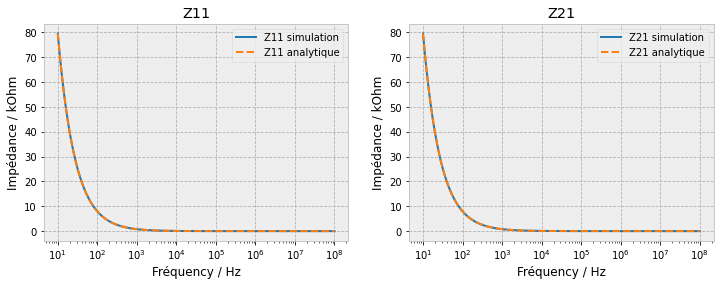

In [178]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.title("Z11")
plt.semilogx(frequency, Z11*1e-3, label="Z11 simulation")
plt.semilogx(frequency, Z11_analytique*1e-3, "--", label="Z11 analytique")
plt.xlabel("Fréquency / Hz")
plt.ylabel("Impédance / kOhm")
plt.legend()

plt.subplot(122)
plt.title("Z21")
plt.semilogx(frequency, Z21*1e-3, label="Z21 simulation")
plt.semilogx(frequency, Z21_analytique*1e-3, "--", label="Z21 analytique")
plt.xlabel("Fréquency / Hz")
plt.ylabel("Impédance / kOhm")
plt.legend()
plt.show()

Il est possible de voir que les résultats sont très proches. Comme cela, il n'est pas possible de voir une différence. Pour voir une différence une il faut zoumer au niveau des hautes fréquences.

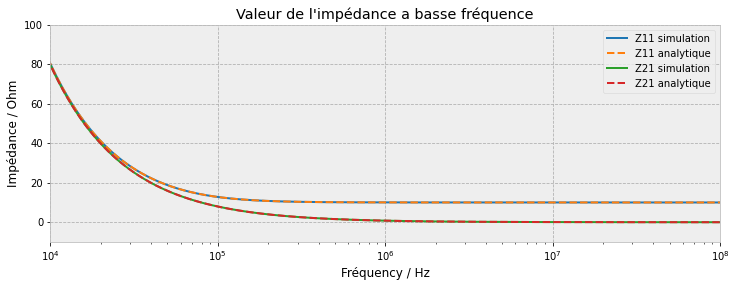

In [179]:
plt.figure(figsize=(12, 4))

plt.title("Valeur de l'impédance a basse fréquence")

plt.semilogx(frequency, Z11, label="Z11 simulation")
plt.semilogx(frequency, Z11_analytique, "--", label="Z11 analytique")

plt.semilogx(frequency, Z21, label="Z21 simulation")
plt.semilogx(frequency, Z21_analytique, "--", label="Z21 analytique")

plt.xlabel("Fréquency / Hz")
plt.ylabel("Impédance / Ohm")
plt.xlim(1e4, 1e8)
plt.ylim(-10, 100)

plt.legend()

plt.show()

Donc la seule différence entre la sortie et l'entrée et la résistance $R$

##### Z22 et Z12

In [180]:
circuit = Circuit('Z22 and Z12-parameter extraction')

# Source de courant AC de test
circuit.SinusoidalCurrentSource(
    'test', 'vout', circuit.gnd, 
    amplitude=Amplitude_wave @ u_A,
    frequency=1 @ u_Hz)  

# RC
circuit.R(1, 'vin', 'vinter', R1 @ u_Ohm)
circuit.C(1, 'vinter', circuit.gnd, C1 @ u_F)
circuit.L(1, 'vinter', 'vout', L1 @ u_H)
circuit.R(2, 'vin', circuit.gnd, 1 @ u_GOhm); # Mandatory for the simulation, 

In [181]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
analysis = simulator.ac(
    start_frequency=10 @ u_Hz,
    stop_frequency=100 @ u_MHz,
    number_of_points=1000,
    variation='dec'
)

In [182]:
# ============================================================
# Extract simulation data
# ============================================================

frequency = np.array(analysis.frequency)

Z22 = np.abs(np.array(analysis['vout']))
Z12 = np.abs(np.array(analysis['vin']))

In [183]:
# ============================================================
# Extract analytique data
# ============================================================
Z22_analytique = np.abs(L1 * 2j * np.pi * frequency  +  1 / ( C1 * 2j * np.pi * frequency))
Z12_analytique = np.abs( 1 / (C1 * 2j * np.pi * frequency))

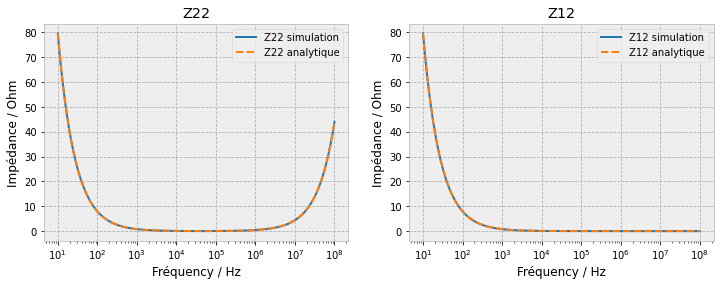

In [184]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.title("Z22")
plt.semilogx(frequency, Z22*1e-3, label="Z22 simulation")
plt.semilogx(frequency, Z22_analytique*1e-3, "--", label="Z22 analytique")
plt.xlabel("Fréquency / Hz")
plt.ylabel("Impédance / Ohm")
plt.legend()

plt.subplot(122)
plt.title("Z12")
plt.semilogx(frequency, Z12*1e-3, label="Z12 simulation")
plt.semilogx(frequency, Z12_analytique*1e-3, "--", label="Z12 analytique")
plt.xlabel("Fréquency / Hz")
plt.ylabel("Impédance / Ohm")
plt.legend()

plt.show()

Donc il est possible de voir que la valeur de la simulation et de la valeur analytique. 

### Matrice Admitance [Y]

#### Equation

L'inverse de la résistance et l'admitance. L'équation de l'admitance et la suivante :

$$Y = \frac{1}{Z}$$

Donc la loi d'ohm devient donc :

$$I = Y \cdot V$$

Donc en repartant du schéma [](#quadripole_resistance), il est possible d'avoir comme équation suivante :

$$
\begin{cases}
I_1 & = & y_{11} V_1 + y_{12} V_2 \\
I_2 & = & y_{21} V_1 + y_{22} V_2
\end{cases}
$$

Pour comprendre les inductance, il est possible de dire la chose suivante sur les montages :
* $y_{11}$ : inductance d'entrée lorsque la sortie est en court-circuit.
  $$V_2 = 0 \Rightarrow  y_{11} = I_1 / V_1$$
* $y_{12}$ : inductance de transfert retour lorque l'entrée est en court-circuit
  $$V_1 = 0 \Rightarrow y_{12} = I_2 / V_1$$
* $y_{22}$ : inductance de sortie lorsque l'entrée est en court-circuit
  $$V_1 = 0 \Rightarrow  y_{22} = I_2 / V_2$$
* $y_{21}$ : inductance de transfert aller lorque la sortie est court-circuit
  $$V_2 = 0 \Rightarrow y_{21} = I_1 / V_2$$


Ainsi, a partir de cela il est possible d'écrire l'équation sous forme de matrice :

$$
\begin{bmatrix}
I_1\\
I_2
\end{bmatrix}
=\begin{bmatrix}
y_{11} & y_{12}\\
y_{21} & y_{22}
\end{bmatrix}
\cdot
\begin{bmatrix}
V_1\\
V_2
\end{bmatrix}
$$

Donc il est possible de simplifier les équations en :

$$
\begin{bmatrix}I\end{bmatrix}
=\begin{bmatrix}Y\end{bmatrix}
\cdot
\begin{bmatrix}V\end{bmatrix}
$$

Une question peut se posé comment obtenir la matrice Y, à partir la matrice Z. Pour cela il faut voir :

$$
\begin{bmatrix}V\end{bmatrix}
=\begin{bmatrix}Z\end{bmatrix}
\cdot
\begin{bmatrix}I\end{bmatrix}
$$

Il est possible d'inverser la matrice Z, pour obtenir la fonction suivant :

$$
\begin{bmatrix}I\end{bmatrix}
=\begin{bmatrix}Z\end{bmatrix}^{-1}
\cdot
\begin{bmatrix}V\end{bmatrix}
$$

Donc il est possible d'écrire l'équation suivante :

$$\begin{bmatrix}Y\end{bmatrix} = \begin{bmatrix}Z\end{bmatrix}^{-1}$$

```{dropdown} Inversion matrice
Pour inverser une matrice 2x2, il faut commencer par calculer son déterminant. Qui vaut :

$$det\left(\begin{bmatrix}
z_{11} & z_{12}\\
z_{21} & z_{22}
\end{bmatrix}\right)
$$

Pour inverser cela il faut faire :
$$det\left(\begin{bmatrix}
a & b\\
c & d
\end{bmatrix}\right) =
a d - b c \neq 0
$$

La matrice peut être inversible que si le déterminant dans la matrice est différent de 0.

$$det\left(\begin{bmatrix}
z_{11} & z_{12}\\
z_{21} & z_{22}
\end{bmatrix}\right) = z_{11} z_{22} - z_{12} z_{21} \neq 0
$$

En posant 

$$\Delta^Z = z_{11} z_{22} - z_{12} z_{21}$$

Maintenant que le déterminant est calculer il est possible de calculer la matrice inversible.

$$
\begin{bmatrix}A\end{bmatrix}^{-1} = \frac{1}{\text{det}(A)} \begin{bmatrix}
d & -b\\
-c & a
\end{bmatrix}
$$

Donc par identification, il est possible d'écire : 

$$
\begin{bmatrix}Y\end{bmatrix} = \begin{bmatrix}Z\end{bmatrix}^{-1} = \begin{bmatrix}
\frac{z_{22}}{\Delta^Z} & \frac{-z_{12}}{\Delta^Z}\\
\frac{-z_{21}}{\Delta^Z} & \frac{z_{11}}{\Delta^Z}
\end{bmatrix}
$$
```

Donc pour passer d'une matrice Z à une matrice Y, il faut faire ce calcule : 

$$
\begin{bmatrix}Y\end{bmatrix} = \begin{bmatrix}
\frac{z_{22}}{\Delta^Z} & \frac{-z_{12}}{\Delta^Z}\\
\frac{-z_{21}}{\Delta^Z} & \frac{z_{11}}{\Delta^Z}
\end{bmatrix}
$$

En posant : 
$$\Delta^Z = z_{11} z_{22} - z_{12} z_{21}$$


#### Théorique

##### Parameter Calculation

L'objectif est toujours de caractériser le circuit suivant [](#montage_test_theorique). En repartant de l'équation trouver pour l'admitance à partir de l'équation des impédance ce n'est pas le cacule le plus trivail.

$$
\begin{cases}
I_1 = \left(\dfrac{Z_2 + Z_3}{Z_1 Z_2 + Z_2 Z_3 + Z_3 Z_1}\right) V_1 - \left(\dfrac{Z_2}{Z_1 Z_2 + Z_2 Z_3 + Z_3 Z_1}\right) V_2 \\
I_2 = - \left(\dfrac{Z_2}{Z_1 Z_2 + Z_2 Z_3 + Z_3 Z_1}\right) V_1 + \left(\dfrac{Z1 + Z_2}{Z_1 Z_2 + Z_2 Z_3 + Z_3 Z_1}\right) V_2
\end{cases}
$$

Il est possible de simplifier les équations en posant :
$$\Delta^Z = Z_1 Z_2 + Z_2 Z_3 + Z_3 Z_1$$
Les équations deviennent :

$$
\begin{cases}
I_1 = \left(\dfrac{Z_2 + Z_3}{\Delta^Z}\right) V_1 - \left(\dfrac{Z_2}{\Delta^Z}\right) V_2 \\
I_2 = - \left(\dfrac{Z_2}{\Delta^Z}\right) V_1 + \left(\dfrac{Z1 + Z_2}{\Delta^Z}\right) V_2
\end{cases}
$$

La démonstration n'est pas compliqué, c'est juste relativement long, mais je pense qu'elle peut être améliorer.

```{dropdown} Demonstration Y avec les impédances des composants.
Tout d'abord, il est possible d'obtenir de revenir à l'équation trouver dans la partie précédente, avec 

$$
\begin{cases}
V_1 = \left(R + \frac{1}{j \omega C}\right) I_1 + \frac{1}{j \omega C} I_2 \\
V_2 = \frac{1}{j \omega C} I_1 + \left(j L \omega + \frac{1}{j \omega C}\right) I_2
\end{cases}
$$

L'objectif est d'isolé $I_1$ et $I_2$. Pour cela en repartant de l'équation de $V_2$ il est possible d'obtenir.

$$Z_2 I_2 = V_1 - (Z_1 + Z_2) I_2$$
$$\boxed{I_2 = \frac{V_1}{z_2} - \frac{Z_1 + Z_2}{Z_2}}$$

En l'injectant dans la première ligne de $V_1$. L'équation devient 
$$V_2 = Z_2 I_1 + (Z_2 + Z_3) I_2$$
$$V_2 = Z_2 I_1 + (Z_2 + Z_3) \left(\frac{V1}{Z_2} - \frac{Z_1+Z_2}{Z_2} \right)$$
$$V_2 = Z_2 I_1 + \frac{Z_2 + Z_3}{Z_2} V_1 - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2} I_1$$

Donc l'objectif est d'isolé $I_1$.

$$Z_2 I_1 - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2} I_1  = V_2 - \frac{Z_2 + Z_3}{Z_2} V_1$$
$$I_1 \left(Z_2 - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2}\right)  = V_2 - \frac{Z_2 + Z_3}{Z_2} V_1$$

L'objectif maintenant est de développer les élément dans la branche de gauche :

$$\left(Z_2 - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2}\right) = \left(\frac{Z^2_2}{Z_2} - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2}\right)$$
$$\left(Z_2 - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2}\right) = \left(\frac{Z^2_2 - Z_1 Z_2 - Z^2_2 - Z_2 Z_3 - Z_3 Z_1}{Z_2}\right)$$
$$\left(Z_2 - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2}\right) = \left(\frac{Z_1 Z_2- Z_2 Z_3 - Z_3 Z_1}{Z_2}\right)$$

Dans le reste de l'étude on pose : 
$$\Delta^Z = Z_1 Z_2- Z_2 Z_3 - Z_3 Z_1$$

Il est donc possible d'otenir :
$$\left(Z_2 - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2}\right) = \left(\frac{\Delta}{Z_2}\right)$$

$$I_1 \left(Z_2 - \frac{(Z_1+Z_2)(Z_2 + Z_3)}{Z_2}\right)  = V_2 - \frac{Z_2 + Z_3}{Z_2} V_1$$
$$I_1 \frac{\Delta^Z}{Z_2}  = V_2 - \frac{Z_2 + Z_3}{Z_2} V_1$$
$$I_1  = \frac{Z_2}{\Delta^Z} \left(V_2 - \frac{Z_2 + Z_3}{Z_2} V_1\right)$$
$$I_1  = - V_2 \frac{Z_2}{\Delta^Z} + \left( \frac{Z_2}{\Delta^Z}{Z_2} \frac{Z_2 + Z_3}{Z_2} V_1\right)$$
$$\boxed{I_1  = \frac{Z_2 + Z_3}{\Delta^Z} V_1 - \frac{Z_2}{\Delta^Z} V_2}$$

Maintenant, il faut faire la même chose mais pour $I_2$

$$I_2 & = & \frac{V_1}{Z_2} - \frac{Z_1 + Z_2}{Z_2} I_1$$
$$\Rightarrow I_2 & = & \frac{V_1}{Z_2} - \frac{Z_1 + Z_2}{Z_2} \left(\frac{Z_2 + Z_3}{\Delta^Z} V_1 - \frac{Z_2}{\Delta^Z} V_2 \right)$$
$$\Rightarrow I_2 & = & \frac{V_1}{Z_2} - \frac{(Z_1 + Z_2)(Z_2 + Z_3)}{Z_ 2 \Delta^Z} V_1 - \left(\frac{Z_1 + Z_2}{Z_2} \frac{Z_2}{\Delta^Z} V_2 \right)$$
$$\Rightarrow I_2 & = & V_1 \frac{\Delta^Z }{Z_2 \Delta^Z} - \frac{Z_1 Z_2  + Z^2_2 + Z_2 Z_3 + Z_3 Z_1}{Z_ 2 \Delta^Z} V_1 + \frac{Z_1 + Z_2}{\Delta^Z} V_2$$
$$\Rightarrow I_2 & = & V_1 \frac{\Delta^Z }{Z_2 \Delta^Z} - \frac{Z_1 Z_2  + Z^2_2 + Z_2 Z_3 + Z_3 Z_1}{Z_ 2 \Delta^Z} V_1 + \frac{Z_1 + Z_2}{\Delta^Z} V_2$$
$$\Rightarrow I_2 & = & V_1 \frac{\Delta }{Z_2 \Delta^Z} - \frac{Z^2_2 + \Delta^Z}{Z_ 2 \Delta^Z} V_1 - \frac{Z_1 + Z_2}{\Delta^Z} V_2$$
$$\Rightarrow I_2 & = & V_1 \frac{\Delta^Z - Z^2_2 - \Delta^Z}{Z_ 2 \Delta^Z} + \frac{Z_1 + Z_2}{\Delta^Z} V_2$$
$$\Rightarrow I_2 & = & - V_1 \frac{Z^2_2}{Z_ 2 \Delta^Z} + \frac{Z_1 + Z_2}{\Delta^Z} V_2$$
$$\boxed{\Rightarrow I_2 =  - V_1 \frac{Z_2}{\Delta^Z} + \frac{Z_1 + Z_2}{\Delta^Z} V_2}$$

Donc on retrouve bien toutes les équations présenté plutôt.
```

```{note}
Le calcul est la version longue, il est possible d'aller beaucoup plus vite avec une simple inversion de matrice en plus dans la partie précédent, il a été montré les équations et cela va relativement plus vite.
```
Maintenant, il est possible d'obenir la matrice d'impédance génrale, pour un circuit en T.

$$
\begin{bmatrix}
I_1\\
I_2
\end{bmatrix}
=\begin{bmatrix}
\dfrac{Z_2 + Z_3}{\Delta^Z} & -\dfrac{Z_2}{\Delta^Z} \\
-\dfrac{Z_2}{\Delta^Z} & \dfrac{Z1 + Z_2}{\Delta^Z}
\end{bmatrix}
\cdot
\begin{bmatrix}
V_1\\
V_2
\end{bmatrix}
$$

By identification, the impedances are:

* $Z_1 = R$
* $Z_2 = \frac{1}{j \omega C}$
* $Z_3 = j \omega L$

Donc dans un premier temps, il est possible de calculer $\Delta^Z$

$$\Delta^Z & = & Z_1 Z_2 + Z_2 Z_3 + Z_3 Z_1$$
$$\Delta^Z & = & R \frac{1}{j \omega C} + \frac{1}{j \omega C} j L \omega + R j \omega L$$
$$\Delta^Z & = & \frac{R}{j \omega C} + \frac{j L \omega}{j \omega C} + R j \omega L$$
$$\Delta^Z & = & \frac{R}{j \omega C} + \frac{j L \omega}{j \omega C} - \frac{R C L \omega^2}{j \omega C}$$
$$\Delta^Z & = & \frac{R - R C L \omega^2 + j L \omega}{j \omega C}$$
$$\Delta^Z & = & \frac{R (1 - C L \omega^2) + j L \omega}{j \omega C}$$

Donc l'équation devient 

$$
\begin{cases}
I_1 = \dfrac{Z_2 + Z_3}{\Delta^Z} V_1 + \dfrac{- Z_2}{\Delta^Z} V_2 \\
I_2 = \dfrac{- Z_2}{\Delta^Z} V_1 + \dfrac{Z_1 + Z_2}{\Delta^Z} V_2
\end{cases}
$$

$$
\begin{cases}
I_1 = \dfrac{\frac{1}{j C \omega}+ j L \omega}{\frac{R (1 - C L \omega^2) + j L \omega}{j \omega C}} V_1 + \dfrac{- \frac{1}{j C \omega}+}{\frac{R (1 - C L \omega^2) + j L \omega}{j \omega C}} V_2 \\
I_2 = \dfrac{- \frac{1}{j C \omega}}{\frac{R (1 - C L \omega^2) + j L \omega}{j \omega C}} V_1 + \dfrac{\frac{1}{j C \omega}+ R}{\frac{R (1 - C L \omega^2) + j L \omega}{j \omega C}} V_2
\end{cases}
$$

$$
\begin{cases}
I_1 = \dfrac{\frac{1 - C L \omega^2}{j C \omega}}{\frac{R (1 - C L \omega^2) + j L \omega}{j \omega C}} V_1 + \dfrac{-1}{R (1 - C L \omega^2) + j L \omega} V_2 \\
I_2 = \dfrac{-1}{R (1 - C L \omega^2) + j L \omega} V_1 + \dfrac{\frac{1 + j C R \omega}{j C \omega}}{\frac{R (1 - C L \omega^2) + j L \omega}{j \omega C}} V_2
\end{cases}
$$


$$
\begin{cases}
I_1 = \dfrac{1 - C L \omega^2}{R (1 - C L \omega^2) + j L \omega} V_1 + \dfrac{-1}{R (1 - C L \omega^2) + j L \omega} V_2 \\
I_2 = \dfrac{-1}{R (1 - C L \omega^2) + j L \omega} V_1 + \dfrac{1 + j C R \omega}{R (1 - C L \omega^2) + j L \omega} V_2
\end{cases}
$$

#### Simulation

L'objectif de cette partie est d'étudier le même système que la partie précédente à savoir [](#montage_test_theorique). Le montage est le même juste, il y a deux petit changement, le premier est qu'il faut changer les sources de courant par des sources de tension. Les circuits-ouvert sont changé par des court-circuit. Donc il n'est pas nécessaire de rajouter une grosse résistance de sortie, comme dans la partie précédente.

##### Y11 et Y21

In [208]:
# =================
# Init Value
# =================
R1 = 10          # Resistance value in Ohms
C1 = 200e-9      # Capacitance value in nF
L1 = 70e-6      # Inductance value in uH

Amplitude_wave = 1   # Amplitude courant

In [209]:
circuit = Circuit('Y11 and 21-parameter extraction')

# Source de courant AC de test
circuit.SinusoidalVoltageSource(
    'test', 'vin', circuit.gnd, 
    amplitude=Amplitude_wave @ u_V,
    frequency=1 @ u_Hz)  

# RC
circuit.R(1, 'vin', 'vinter', R1 @ u_Ohm)
circuit.C(1, 'vinter', circuit.gnd, C1 @ u_F)
circuit.L(1, 'vinter', 'vout', L1 @ u_H)
circuit.R(2, 'vout', circuit.gnd, 1e-9 @ u_Ohm) # Mandatory for the simulation, 

circuit.R1.minus.add_current_probe(circuit)
circuit.L1.minus.add_current_probe(circuit)

In [210]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
analysis = simulator.ac(
    start_frequency=10 @ u_Hz,
    stop_frequency=100 @ u_MHz,
    number_of_points=1000,
    variation='dec'
)

In [211]:
# ============================================================
# Extract simulation data
# ============================================================

frequency = np.array(analysis.frequency)

Y11 = np.abs(np.array(analysis.branches["vr1_minus"]))
Y21 = np.abs(np.array(analysis.branches["vl1_minus"]))

In [212]:
# ============================================================
# Extract analytique data
# ============================================================
w = 2 * np.pi * frequency
delta = R1 * (1 - C1 * L1 * w**2) + 1j * L1 * w

Y11_analytique = np.abs((1 - C1*L1*w**2) / delta)
Y21_analytique = np.abs( - 1 / delta)

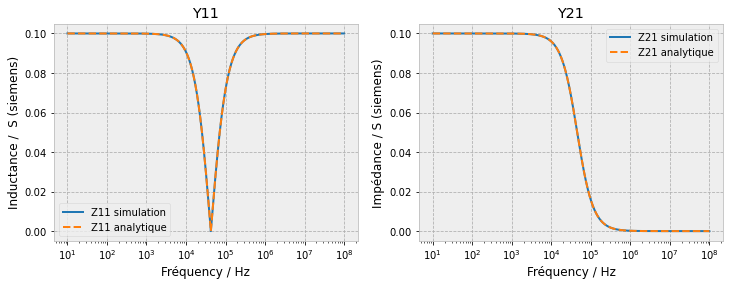

In [213]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.title("Y11")
plt.semilogx(frequency, Y11, label="Z11 simulation")
plt.semilogx(frequency, Y11_analytique, "--", label="Z11 analytique")
plt.xlabel("Fréquency / Hz")
plt.ylabel("Inductance /  S (siemens)")
plt.legend()

plt.subplot(122)
plt.title("Y21")
plt.semilogx(frequency, Y21, label="Z21 simulation")
plt.semilogx(frequency, Y21_analytique, "--", label="Z21 analytique")
plt.xlabel("Fréquency / Hz")
plt.ylabel("Impédance / S (siemens)")
plt.legend()
plt.show()

Donc, il est possible de voir un certain nombre de chose, tout d'abord, d'utiliser les l'inductance rend souvent les graphiques pour lisible lorsqu'il y a des très grosse valeur de résistance. D'autre part, il est possible de voir l'effet pour l'entrée de l'effet passe-bande.

In [215]:
circuit = Circuit('Y22 and 12-parameter extraction')

# Source de courant AC de test
circuit.SinusoidalVoltageSource(
    'test', 'vout', circuit.gnd, 
    amplitude=Amplitude_wave @ u_V,
    frequency=1 @ u_Hz)  

# RC
circuit.R(1, 'vin', 'vinter', R1 @ u_Ohm)
circuit.C(1, 'vinter', circuit.gnd, C1 @ u_F)
circuit.L(1, 'vinter', 'vout', L1 @ u_H)
circuit.R(2, 'vin', circuit.gnd, 1e-9 @ u_Ohm) # Mandatory for the simulation, 

circuit.R1.minus.add_current_probe(circuit)
circuit.L1.minus.add_current_probe(circuit)

In [216]:
# ============================================================
# Simulation Setup
# Transient analysis of the CMOS logic gate
# ============================================================

# Create the simulator instance
# Temperature parameters are set to nominal operating conditions
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# ============================================================
# Transient Analysis
# ============================================================

# Perform a transient simulation to observe the dynamic behavior
analysis = simulator.ac(
    start_frequency=10 @ u_Hz,
    stop_frequency=100 @ u_MHz,
    number_of_points=1000,
    variation='dec'
)

In [217]:
# ============================================================
# Extract simulation data
# ============================================================

frequency = np.array(analysis.frequency)

Y12 = np.abs(np.array(analysis.branches["vr1_minus"]))
Y22 = np.abs(np.array(analysis.branches["vl1_minus"]))

In [218]:
# ============================================================
# Extract analytique data
# ============================================================
w = 2 * np.pi * frequency
delta = R1 * (1 - C1 * L1 * w**2) + 1j * L1 * w

Y22_analytique = np.abs((1 + 1j*R1*C1*w) / delta)
Y12_analytique = np.abs( - 1 / delta)

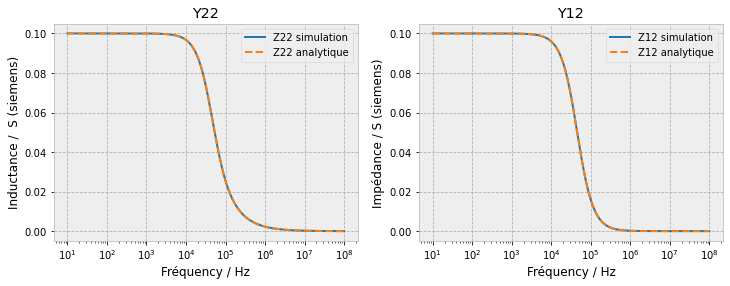

In [219]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.title("Y22")
plt.semilogx(frequency, Y22, label="Y22 simulation")
plt.semilogx(frequency, Y22_analytique, "--", label="Y22 analytique")
plt.xlabel("Fréquency / Hz")
plt.ylabel("Inductance /  S (siemens)")
plt.legend()

plt.subplot(122)
plt.title("Y12")
plt.semilogx(frequency, Y12, label="Y12 simulation")
plt.semilogx(frequency, Y12_analytique, "--", label="Y12 analytique")
plt.xlabel("Fréquency / Hz")
plt.ylabel("Impédance / S (siemens)")
plt.legend()
plt.show()

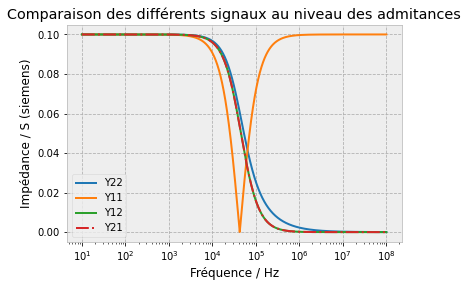

In [228]:
plt.figure()
plt.title("Comparaison des différents signaux au niveau des admitances")
plt.semilogx(frequency, Y22, label="Y22")
plt.semilogx(frequency, Y11, label="Y11")
plt.semilogx(frequency, Y12, label="Y12")
plt.semilogx(frequency, Y21, "-.", label="Y21")
plt.legend()
plt.xlabel("Fréquence / Hz")
plt.ylabel("Impédance / S (siemens)")
plt.show()

Dans la suite, l'objectif est d'aller voir d'autre type de matrice. Qui vont surtout servire pour les connections de matrices. 

### Matrice Hybride [H]

Les matrices hybrides sont des matrices qui sont très pratique pour caractériser les transistors. C'est quand l'entrée, il faut le courant d'entrée et la tension de sortie est cela permet de caractériser le courant de sortie et de la tension d'entrée. L'équation est la suivante :

$$

### Matrice Hybride Inverse [G] 

### Matrice de Transfert [T] ou [A, B, C, D]

### Resumer des matrices


#### Déterminant

Pour rapel, pour avoir le déterminant, il faut faire la somme des termes dans la diagonal puis de soustraire les deux termes qui ont été obtenue. Pour rapel la position des éléments pour une marice Z, mais la position des éléments et la même pour tous les éléments. 

$$
\begin{bmatrix}
z_{11} & z_{12}\\
z_{21} & z_{22}
\end{bmatrix}
$$

Donc pour otbenir les déterminant, il faut faire les équations suivantes :

$$\Delta^z = z_{11} z_{22} - z_{12} z_{21}$$
$$\Delta^y = y_{11} y_{22} - y_{12} y_{21}$$
$$\Delta^h = h_{11} h_{22} - h_{12} h_{21}$$
$$\Delta^g = g_{11} g_{22} - g_{12} g_{21}$$
$$\Delta^a = a_{11} a_{22} - a_{12} a_{21}$$
$$\Delta^b = b_{11} b_{22} - b_{12} b_{21}$$




```{table} Determinant Interrelation
:name: determinant_interrelation
:align: center

|            |            z             |            y             |            h              |           g              |           a              |           b              |
| ---------- | ------------------------ | ------------------------ | ------------------------- |------------------------- | ------------------------- | ------------------------- |
| $\Delta^z$ |            -             | $\dfrac{1}{\Delta^y}$    | $\dfrac{h_{11}}{h_{22}}$  | $\dfrac{g_{22}}{g_{11}}$  | $\dfrac{a_{12}}{a_{21}}$  |$\dfrac{b_{12}}{b_{21}}$  |
| $\Delta^y$ | $\dfrac{1}{\Delta^z}$    |            -             | $\dfrac{h_{22}}{h_{11}}$  | $\dfrac{g_{11}}{g_{22}}$  | $\dfrac{a_{21}}{a_{11}}$  |$\dfrac{b_{21}}{b_{12}}$  |
| $\Delta^h$ | $\dfrac{z_{11}}{z_{22}}$ | $\dfrac{y_{22}}{y_{11}}$ |            -              | $\dfrac{1}{\Delta^g}$     | $\dfrac{a_{11}}{a_{22}}$  |$\dfrac{b_{22}}{b_{11}}$  |
| $\Delta^g$ | $\dfrac{z_{22}}{z_{11}}$ | $\dfrac{y_{11}}{y_{22}}$ | $\dfrac{1}{\Delta^h}$     |            -               | $\dfrac{a_{22}}{a_{11}}$  |$\dfrac{b_{11}}{b_{22}}$  |
| $\Delta^a$ | $\dfrac{z_{12}}{z_{21}}$ | $\dfrac{y_{12}}{y_{21}}$ | $-\dfrac{h_{12}}{h_{21}}$ | $-\dfrac{g_{12}}{g_{21}}$  |            -              | $\dfrac{1}{\Delta^b}$    |
| $\Delta^b$ | $\dfrac{z_{21}}{z_{12}}$ | $\dfrac{y_{21}}{y_{12}}$ | $-\dfrac{h_{21}}{h_{12}}$ | $-\dfrac{g_{21}}{g_{12}}$  | $\dfrac{1}{\Delta^a}$     |            -             |
```

## Type de quadripôle

**Lien à regarder**
* https://www.youtube.com/watch?v=boIiMLR37kA
* https://www.youtube.com/watch?v=_bqa_I5hNAo
* https://www.youtube.com/watch?v=1WPJdAW-sFo
* https://www.youtube.com/watch?v=7TybETlCslM&t=950s